# mBERT Multi-Label Classification (Single File)

This notebook trains mBERT using a **single consolidated dataset file** (`dataset_full.xlsx`).

## Features
- **Standalone**: No dependency on other folders.
- **Data**: Uses `dataset_full.xlsx` containing text, Primary, and Secondary emotions.
- **Split**: Automatically splits data into Train/Val.
- **Model**: `bert-base-multilingual-cased`.

In [1]:
!pip install transformers accelerate scikit-learn openpyxl -q

In [2]:
import os
import json
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

2026-02-03 10:19:12.257856: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770113952.457623      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770113952.518022      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770113953.046942      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770113953.046985      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770113953.046988      55 computation_placer.cc:177] computation placer alr

Using device: cuda


In [3]:
# --- CONFIGURATION ---
# Handle Kaggle vs Local paths automatically
INPUT_FILE = '/kaggle/input/newdata/dataset_full.xlsx'
DATA_DIR = '.'

if os.path.exists('/kaggle/input'):
    # Standard Kaggle Input path check
    for root, _, files in os.walk('/kaggle/input'):
        if INPUT_FILE in files:
            DATA_DIR = root
            break
    OUTPUT_DIR = '/kaggle/working'
else:
    OUTPUT_DIR = 'models_single_file'

FILE_PATH = os.path.join(DATA_DIR, INPUT_FILE)
print(f"Dataset: {FILE_PATH}")
print(f"Output: {OUTPUT_DIR}")
os.makedirs(OUTPUT_DIR, exist_ok=True)

Dataset: /kaggle/input/newdata/dataset_full.xlsx
Output: /kaggle/working


In [4]:
# Load Data
if os.path.exists(FILE_PATH):
    df = pd.read_excel(FILE_PATH)
    print(f"Loaded {len(df)} rows.")
    print(df.head(2))
else:
    raise FileNotFoundError(f"{FILE_PATH} not found. Please ensure dataset_full.xlsx is present.")

# Preprocessing: Fill NaNs
df['text'] = df['text'].fillna('')
df['Primary'] = df['Primary'].fillna('')
df['Secondary'] = df['Secondary'].fillna('')

Loaded 4124 rows.
                                                text  Primary Secondary
0  கெடல்வேண்டின் கேளாது செய்க அடல்வேண்டின் ஆற்று ...  Caution   Respect
1  ஊனைக் குறித்த உயிரெல்லாம் நாண்என்னும் நன்மை கு...  Modesty      Love


In [5]:
# Label Mapping
primary_set = set(df['Primary'].unique()) - {''}
secondary_set = set(df['Secondary'].unique()) - {''}
all_labels = sorted(list(primary_set.union(secondary_set)))

label_map = {label: i for i, label in enumerate(all_labels)}
num_classes = len(all_labels)
print(f"Unique Labels: {num_classes}")

Unique Labels: 65


In [6]:
# Create Targets
def create_targets(df, label_map):
    targets = []
    for _, row in df.iterrows():
        vec = np.zeros(len(label_map), dtype=np.float32)
        # Primary
        if row['Primary'] in label_map:
            vec[label_map[row['Primary']]] = 1.0
        # Secondary
        if row['Secondary'] in label_map:
            vec[label_map[row['Secondary']]] = 1.0
        targets.append(vec)
    return np.array(targets)

y_all = create_targets(df, label_map)
X_all = df['text'].values

# Split Data
X_train, X_val, y_train, y_val = train_test_split(X_all, y_all, test_size=0.2, random_state=42)
print(f"Train: {len(X_train)}, Val: {len(X_val)}")

Train: 3299, Val: 825


In [7]:
# Dataset
class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len
        
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.float)
        }

model_name = 'bert-base-multilingual-cased'
tokenizer = BertTokenizer.from_pretrained(model_name)

train_ds = TextDataset(X_train, y_train, tokenizer)
val_ds = TextDataset(X_val, y_val, tokenizer)

train_dl = DataLoader(train_ds, batch_size=16, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=16)

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

In [8]:
# Model
model = BertForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_classes,
    problem_type="multi_label_classification"
)
model = model.to(device)
optimizer = AdamW(model.parameters(), lr=2e-5)

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [9]:
# Training Loops
def train_step(model, dl):
    model.train()
    total_loss = 0
    for batch in tqdm(dl, desc="Train"):
        input_ids = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        lbls = batch['labels'].to(device)
        
        optimizer.zero_grad()
        output = model(input_ids, attention_mask=mask, labels=lbls)
        loss = output.loss
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(dl)

def eval_step(model, dl):
    model.eval()
    total_loss = 0
    all_preds = []
    all_true = []
    
    with torch.no_grad():
        for batch in dl:
            input_ids = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)
            lbls = batch['labels'].to(device)
            
            output = model(input_ids, attention_mask=mask, labels=lbls)
            total_loss += output.loss.item()
            
            probs = torch.sigmoid(output.logits).cpu().numpy()
            all_preds.extend(probs)
            all_true.extend(lbls.cpu().numpy())
            
    # Metrics
    preds_bin = (np.array(all_preds) > 0.5).astype(int)
    true_bin = np.array(all_true).astype(int)
    
    f1_mic = f1_score(true_bin, preds_bin, average='micro', zero_division=0)
    f1_samp = f1_score(true_bin, preds_bin, average='samples', zero_division=0)
    acc = accuracy_score(true_bin, preds_bin)
    
    return total_loss / len(dl), f1_mic, f1_samp, acc

Epoch 1/17


Train:   0%|          | 0/207 [00:00<?, ?it/s]

Train Loss: 0.2532 | Val Loss: 0.1223
Micro F1: 0.0000 | Sample F1: 0.0000 | Acc: 0.0000
Epoch 2/17


Train:   0%|          | 0/207 [00:00<?, ?it/s]

Train Loss: 0.1111 | Val Loss: 0.1012
Micro F1: 0.0000 | Sample F1: 0.0000 | Acc: 0.0000
Epoch 3/17


...

Train Loss: 0.0566 | Val Loss: 0.0815
Micro F1: 0.4204 | Sample F1: 0.3463 | Acc: 0.1758
Saved Best Model!
Epoch 16/17


Train:   0%|          | 0/207 [00:00<?, ?it/s]

Train Loss: 0.0540 | Val Loss: 0.0820
Micro F1: 0.3926 | Sample F1: 0.3198 | Acc: 0.1467
Epoch 17/17


Train:   0%|          | 0/207 [00:00<?, ?it/s]

Train Loss: 0.0521 | Val Loss: 0.0821
Micro F1: 0.4028 | Sample F1: 0.3402 | Acc: 0.1576


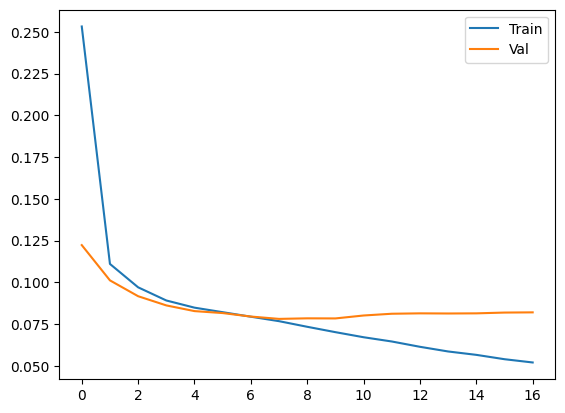

In [10]:
# Execute
EPOCHS = 17
history = {'train_loss': [], 'val_loss': [], 'val_f1': []}
best_score = 0

for epoch in range(EPOCHS):
    print(f"Epoch {epoch+1}/{EPOCHS}")
    t_loss = train_step(model, train_dl)
    v_loss, f1_mic, f1_samp, acc = eval_step(model, val_dl)
    
    print(f"Train Loss: {t_loss:.4f} | Val Loss: {v_loss:.4f}")
    print(f"Micro F1: {f1_mic:.4f} | Sample F1: {f1_samp:.4f} | Acc: {acc:.4f}")
    
    history['train_loss'].append(t_loss)
    history['val_loss'].append(v_loss)
    history['val_f1'].append(f1_mic)
    
    if f1_mic > best_score:
        best_score = f1_mic
        model.save_pretrained(os.path.join(OUTPUT_DIR, 'best_model'))
        tokenizer.save_pretrained(os.path.join(OUTPUT_DIR, 'best_model'))
        print("Saved Best Model!")

# Save History
with open(os.path.join(OUTPUT_DIR, 'history.json'), 'w') as f:
    json.dump(history, f)
    
plt.plot(history['train_loss'], label='Train')
plt.plot(history['val_loss'], label='Val')
plt.legend()
plt.show()

Confusion Matrix Eval:   0%|          | 0/52 [00:00<?, ?it/s]

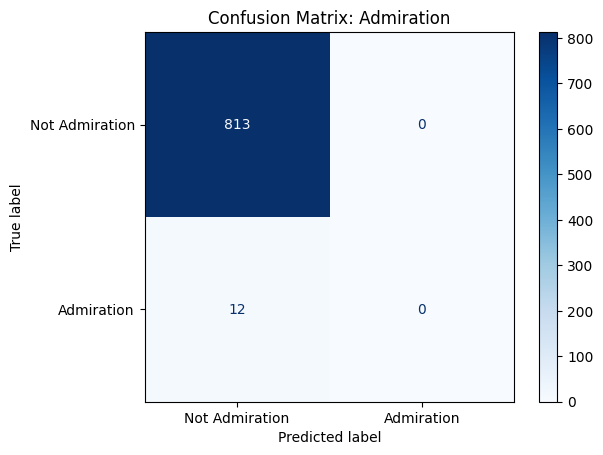

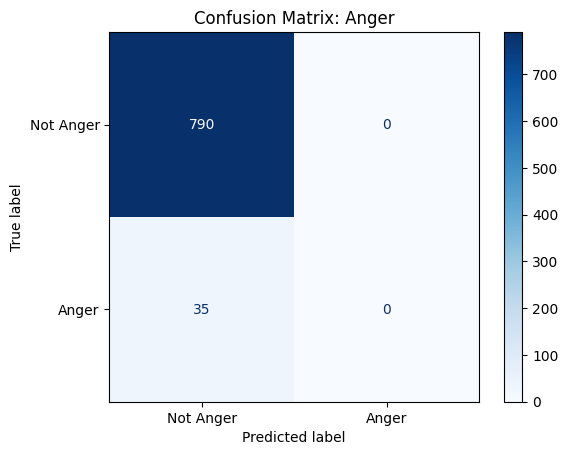

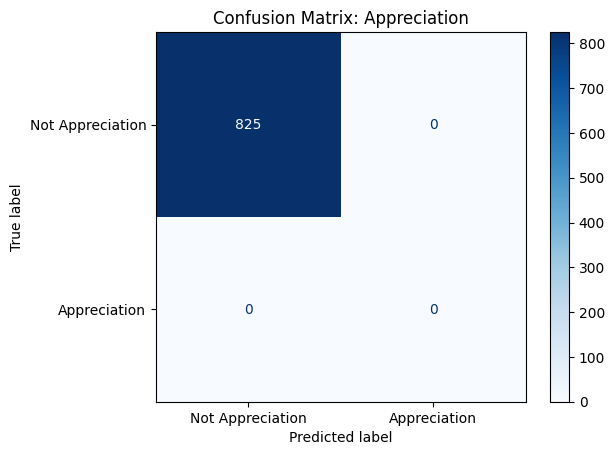

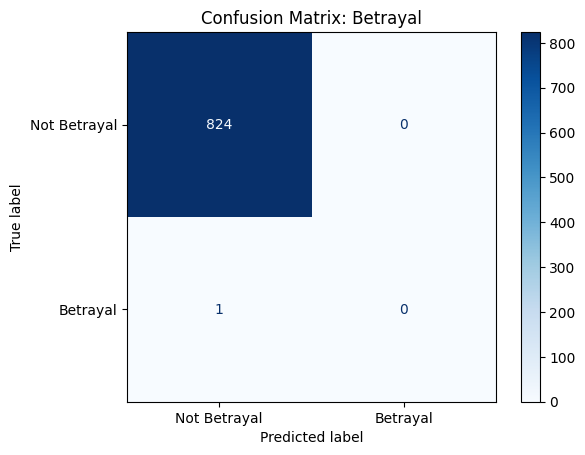

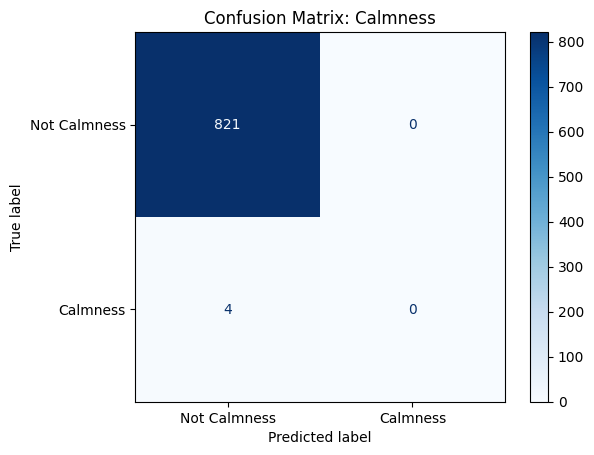

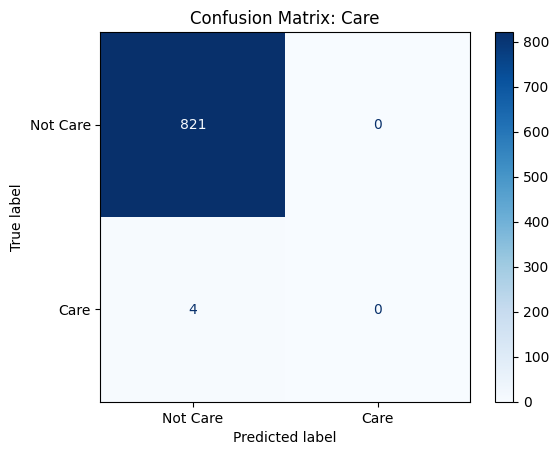

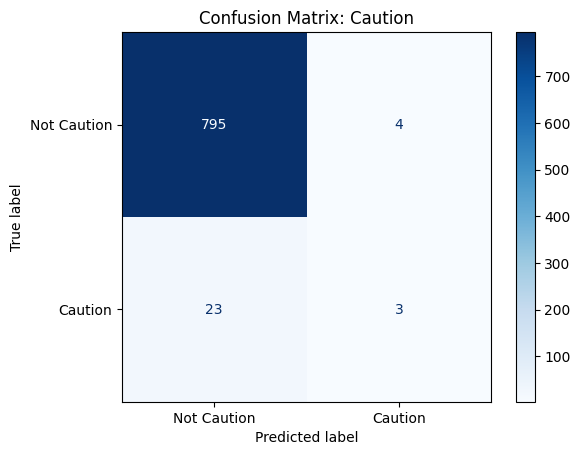

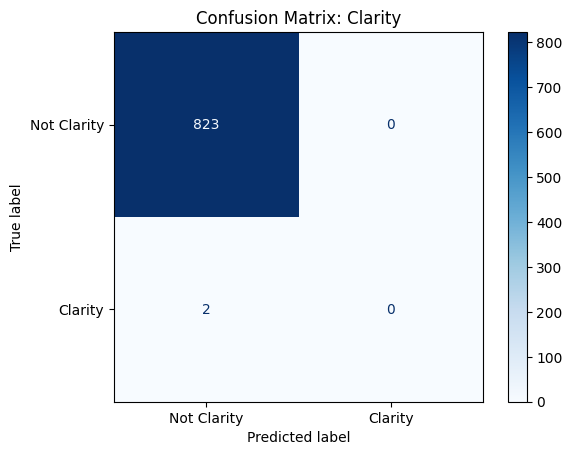

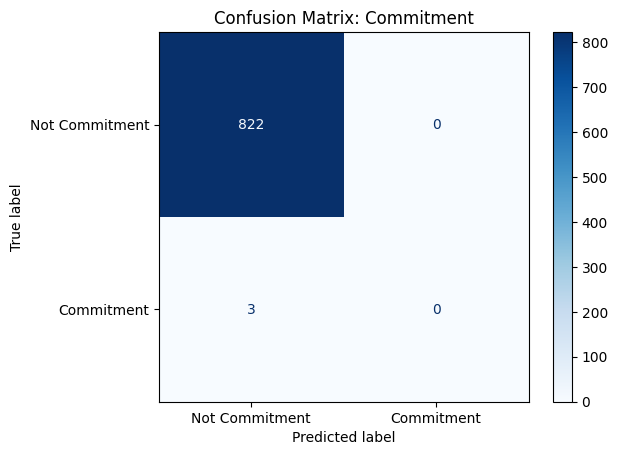

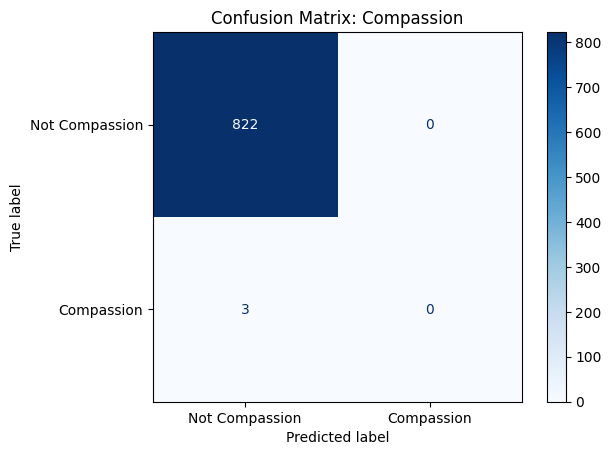

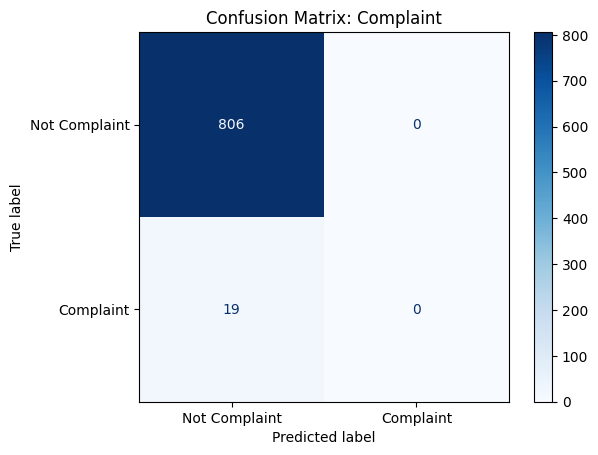

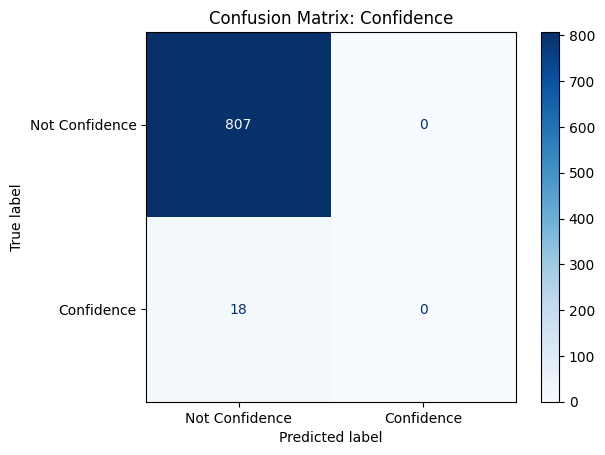

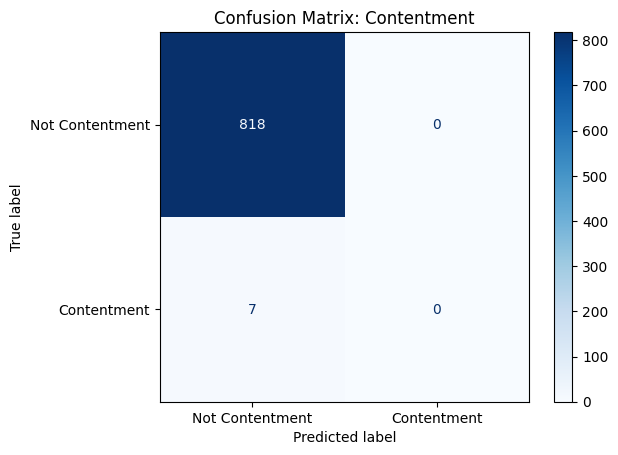

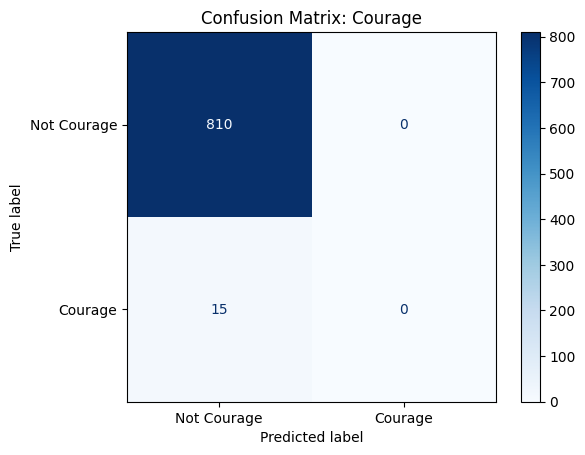

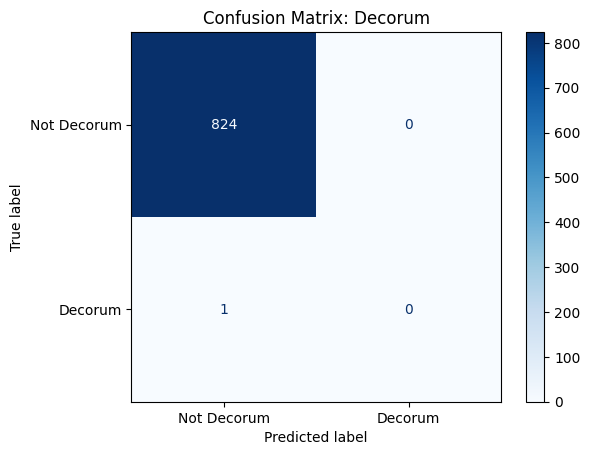

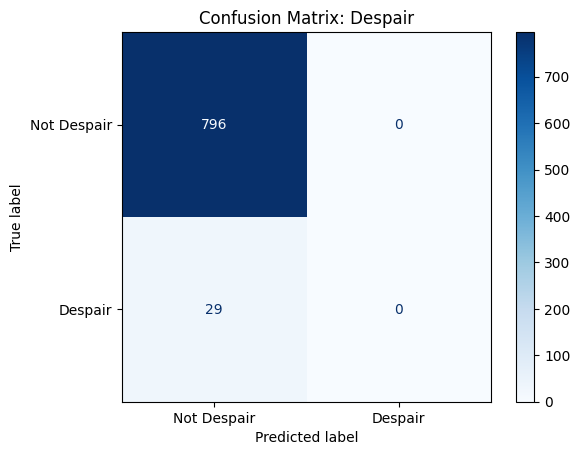

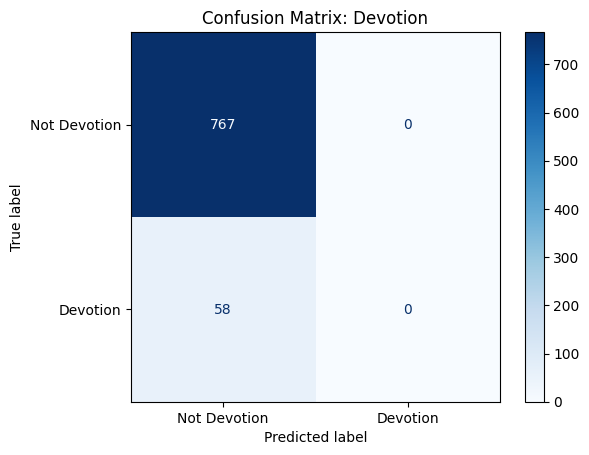

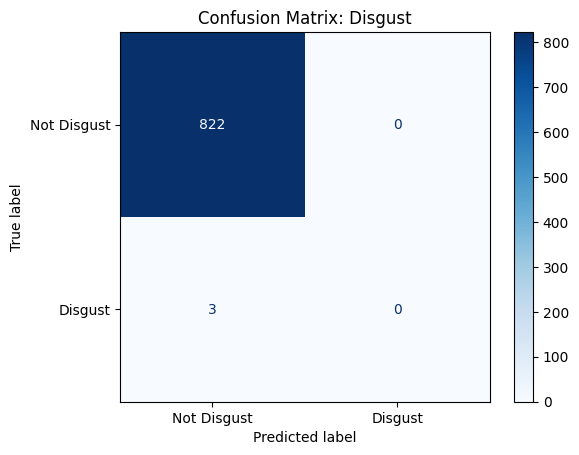

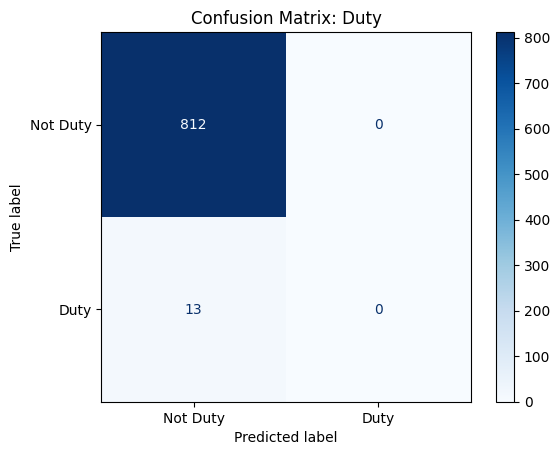

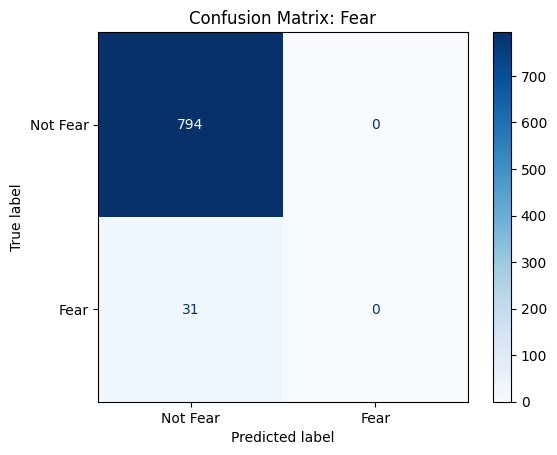

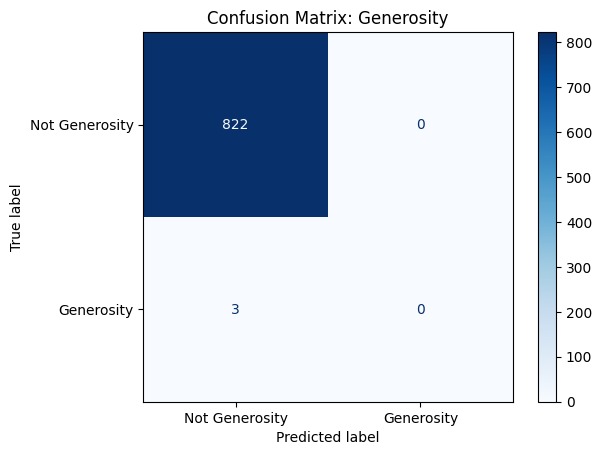

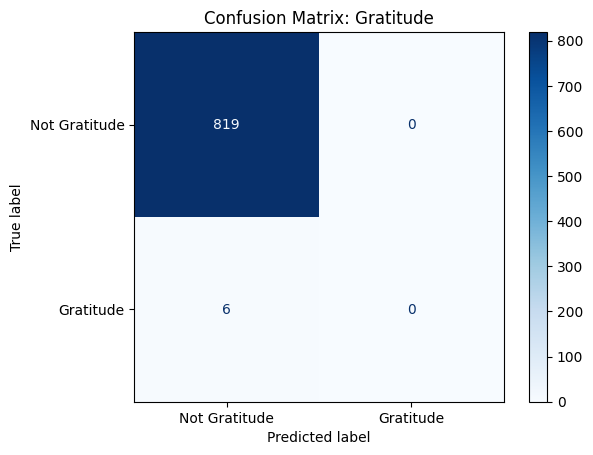

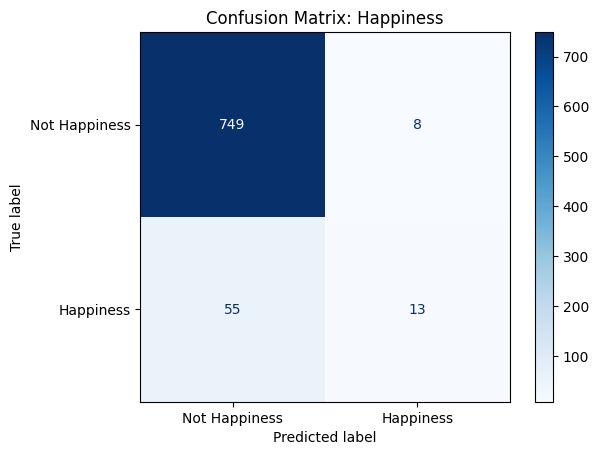

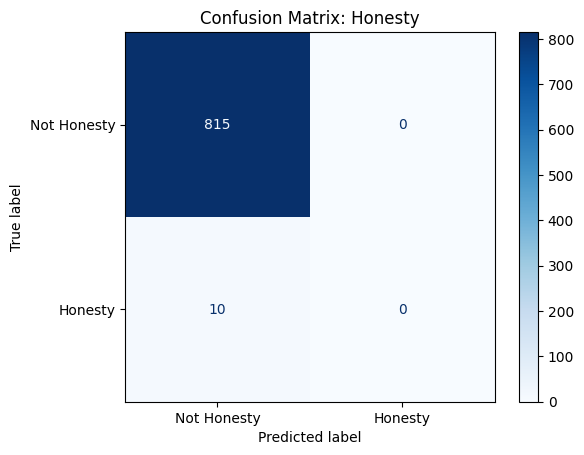

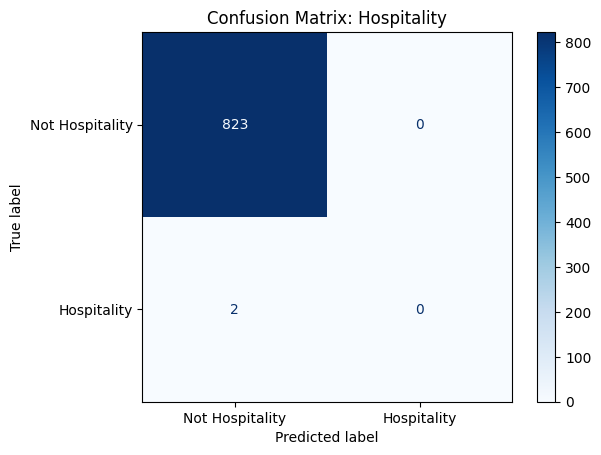

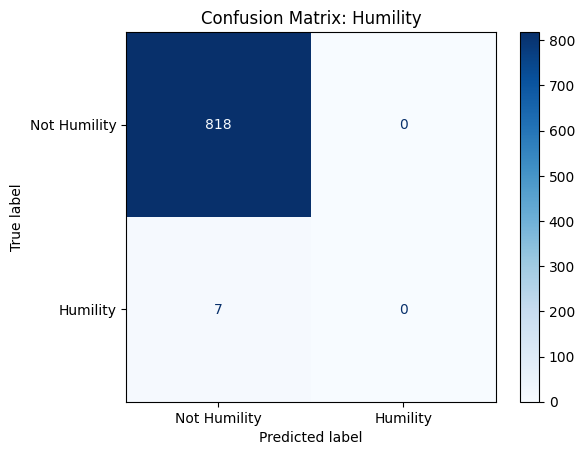

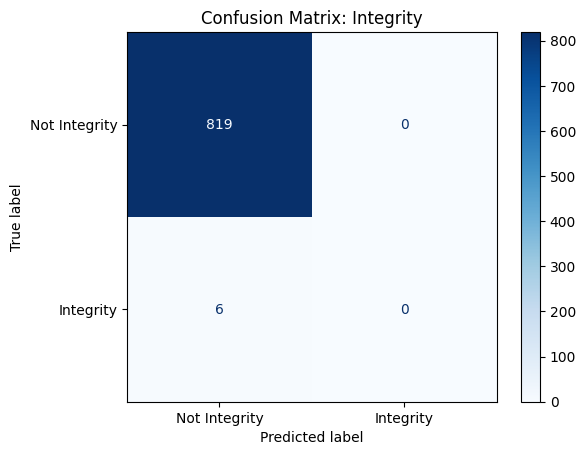

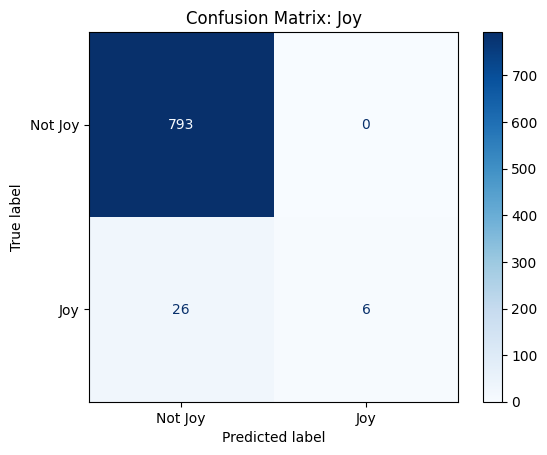

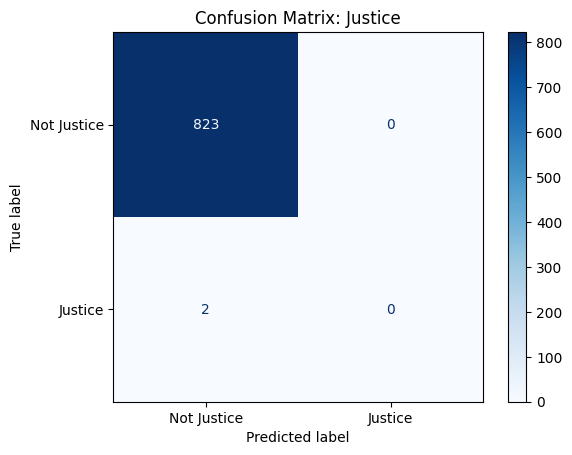

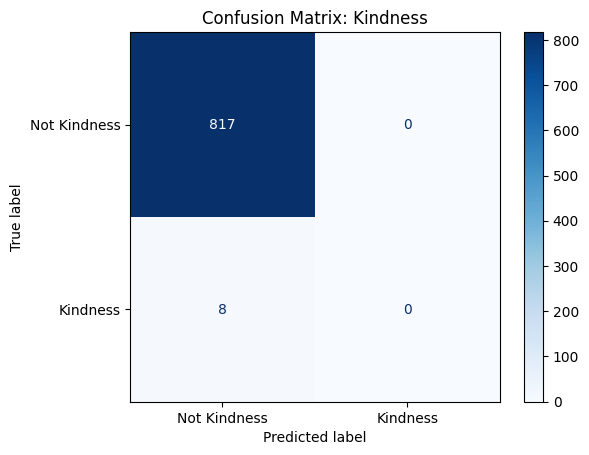

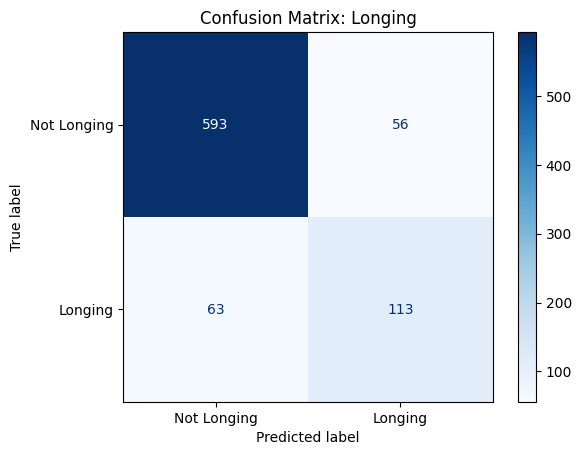

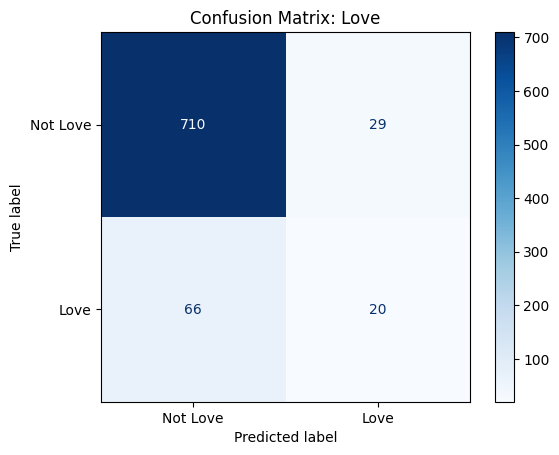

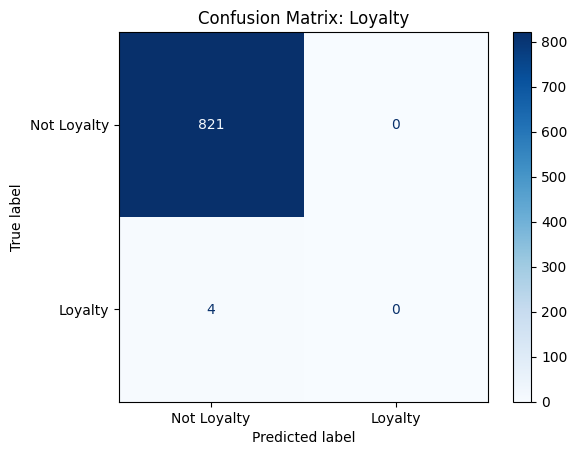

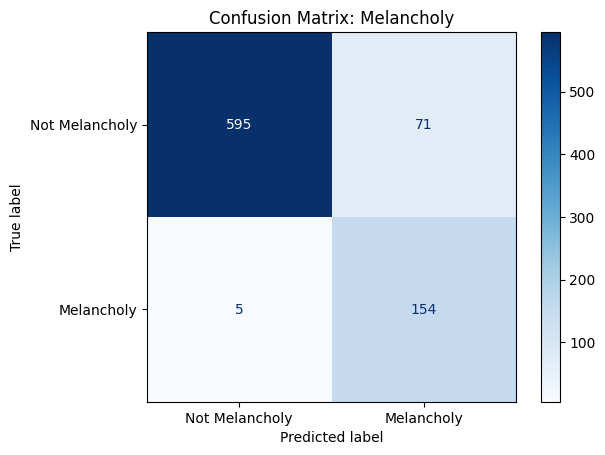

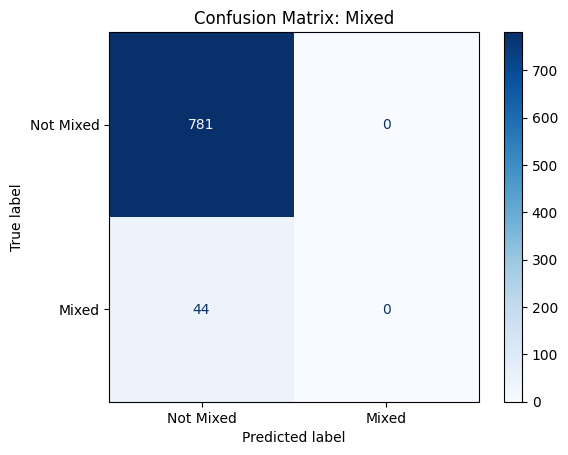

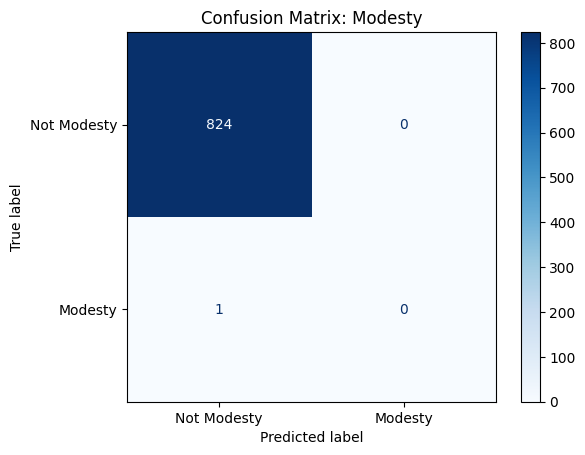

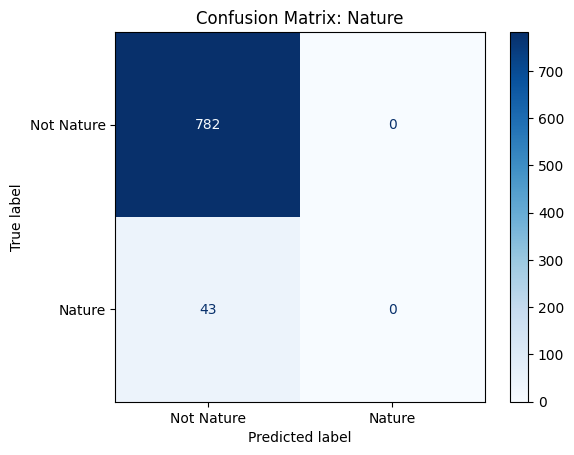

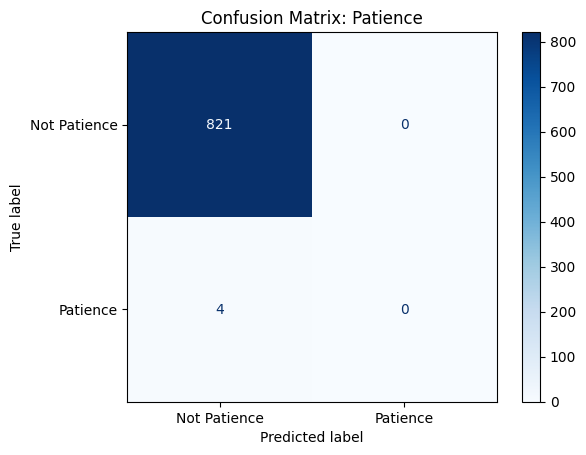

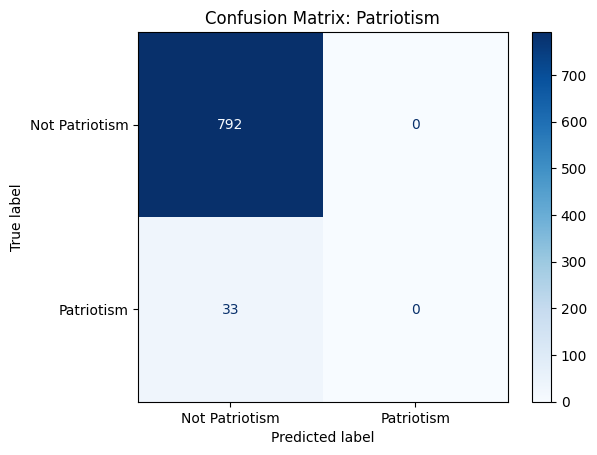

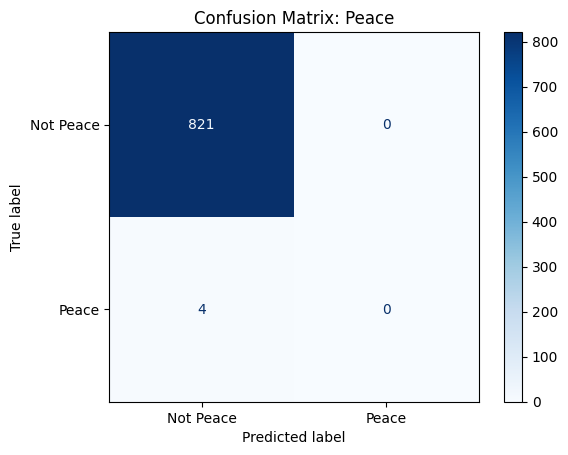

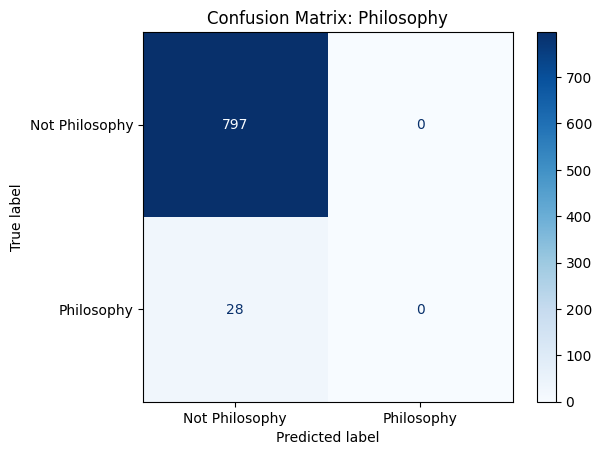

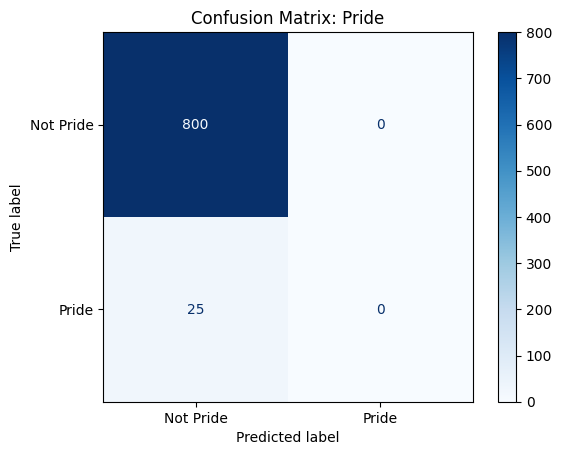

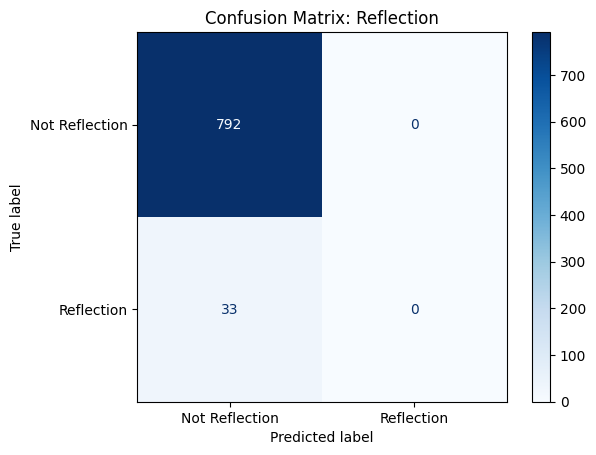

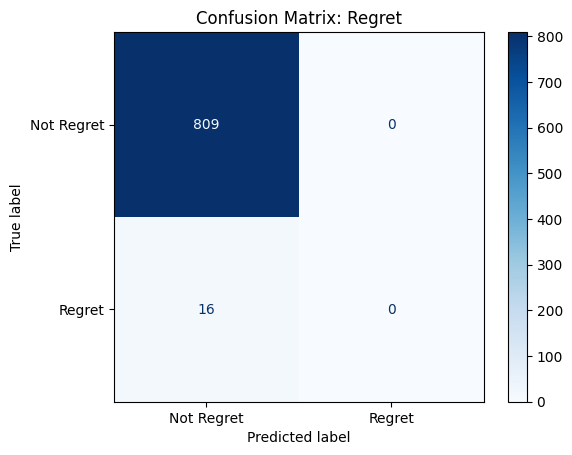

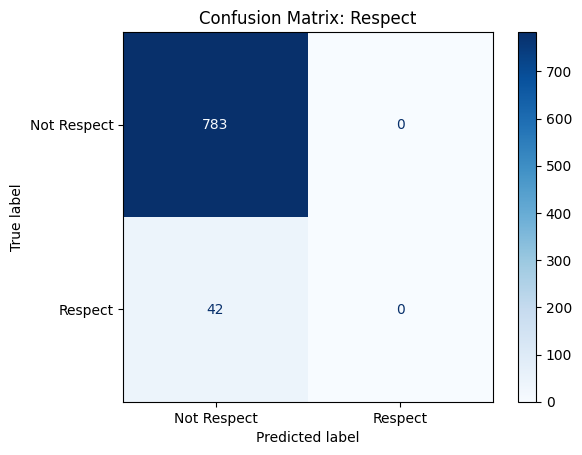

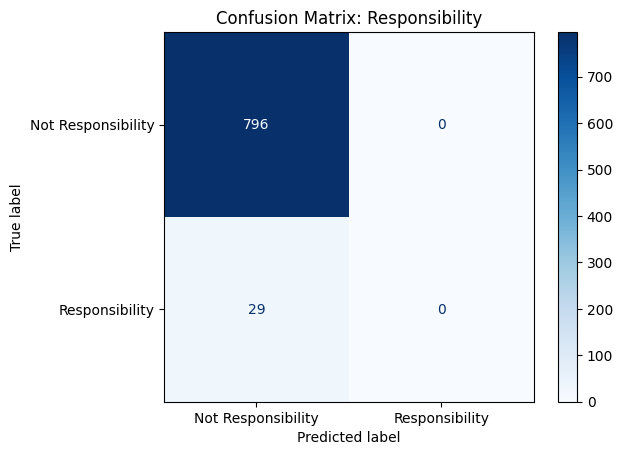

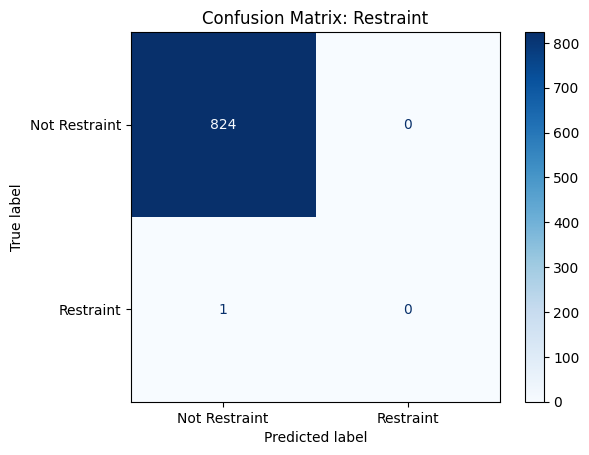

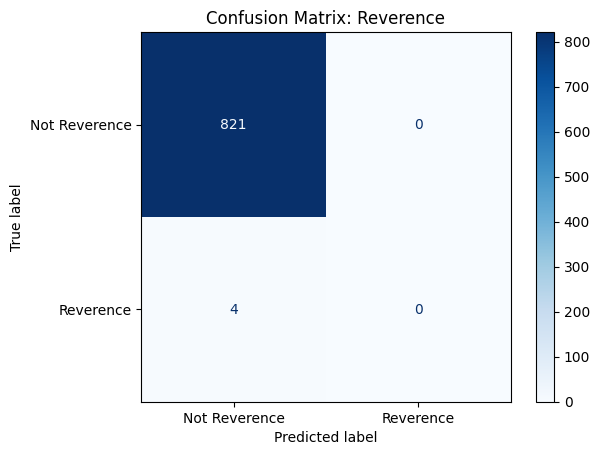

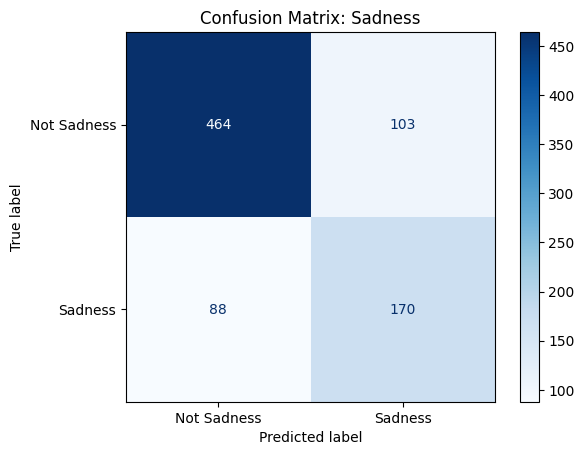

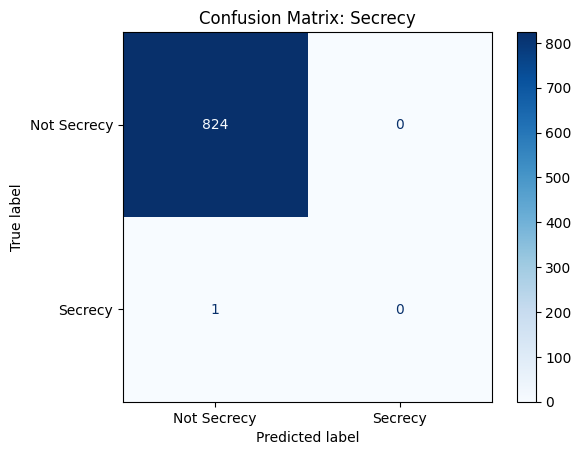

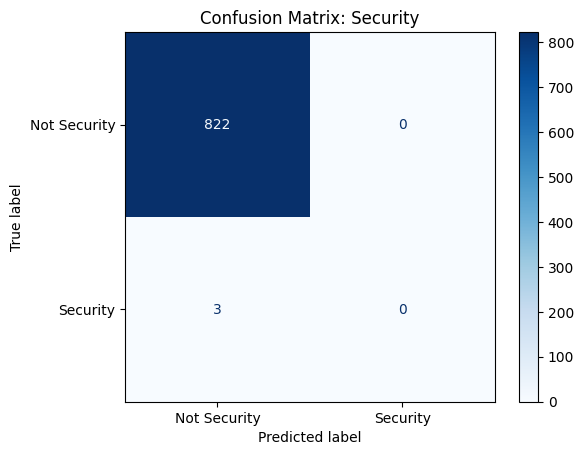

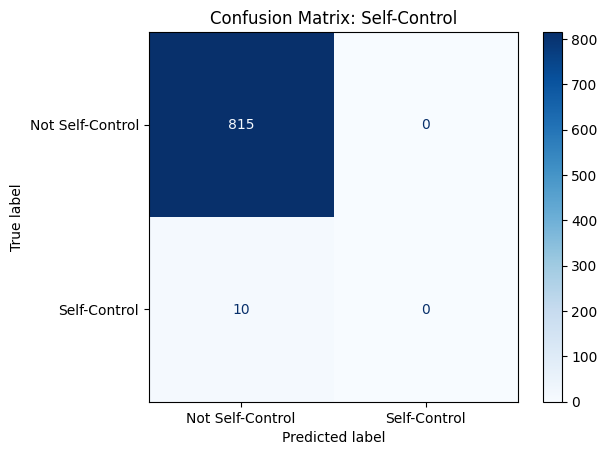

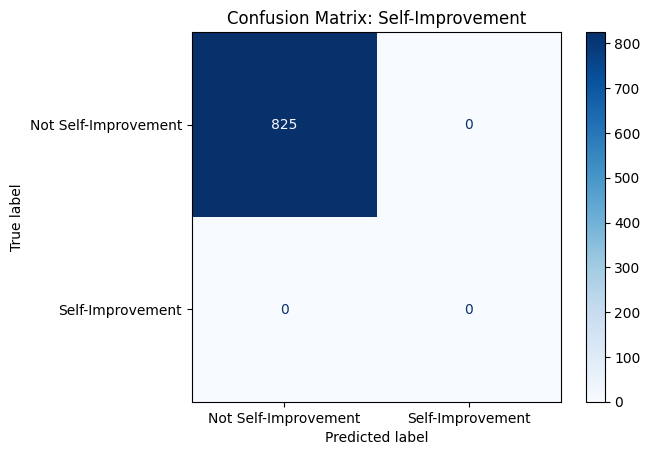

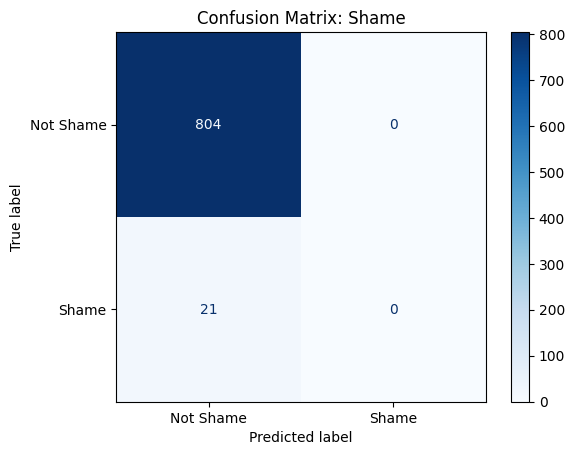

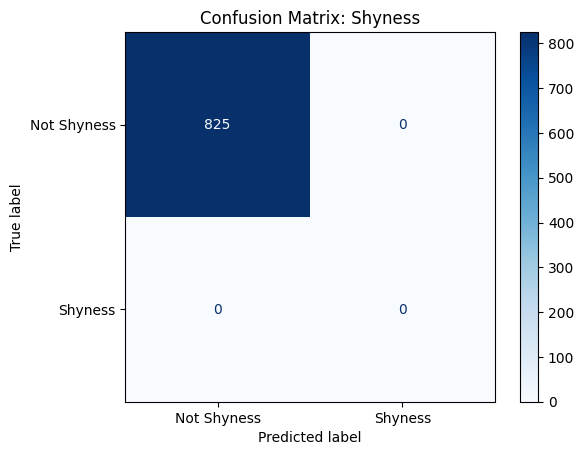

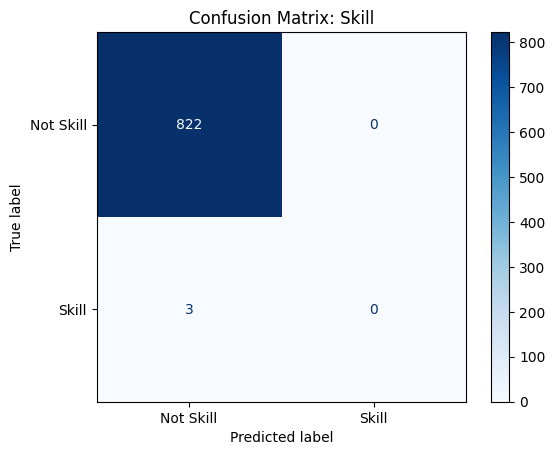

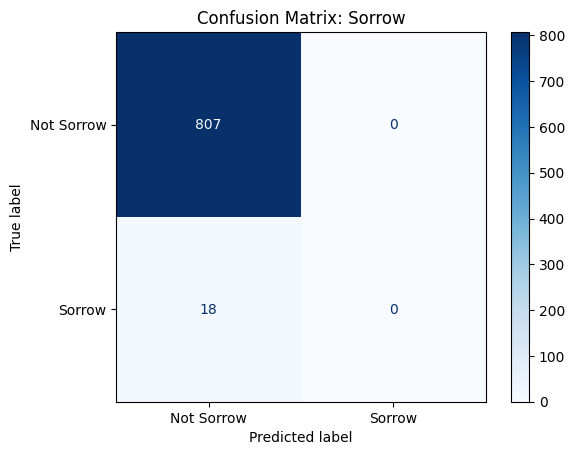

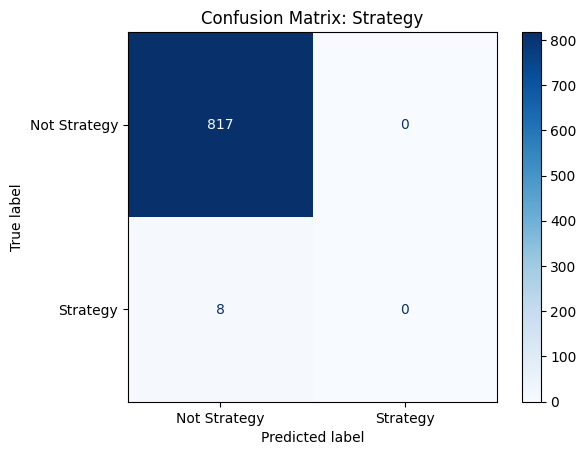

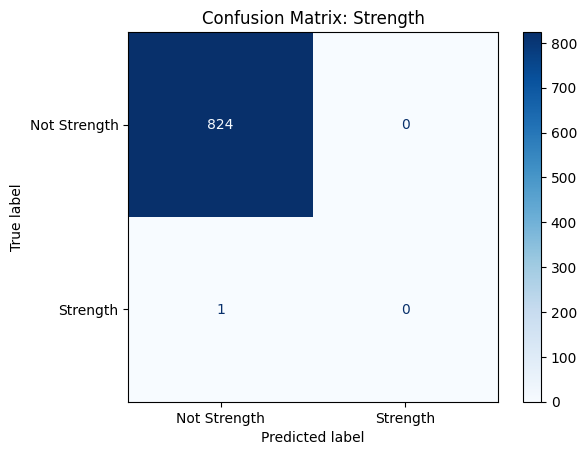

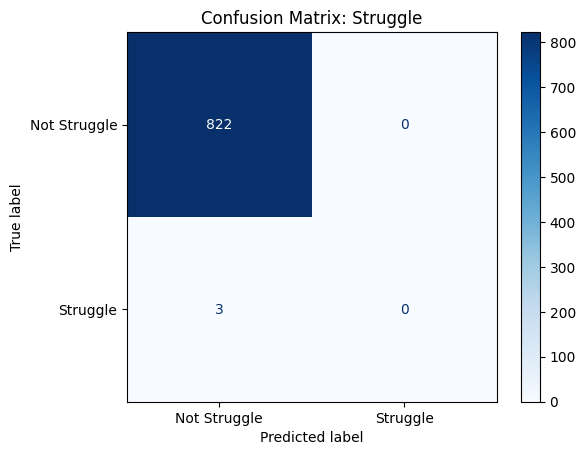

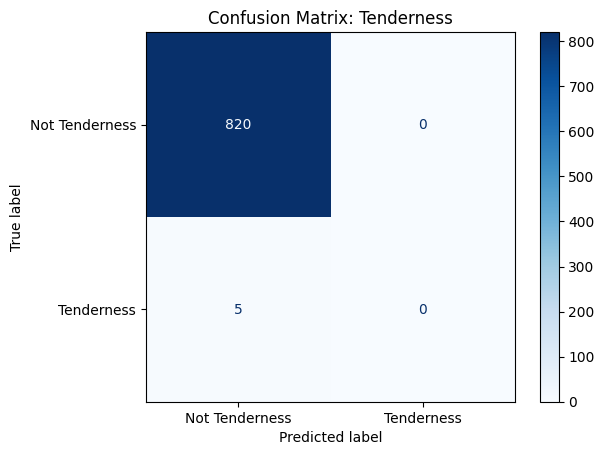

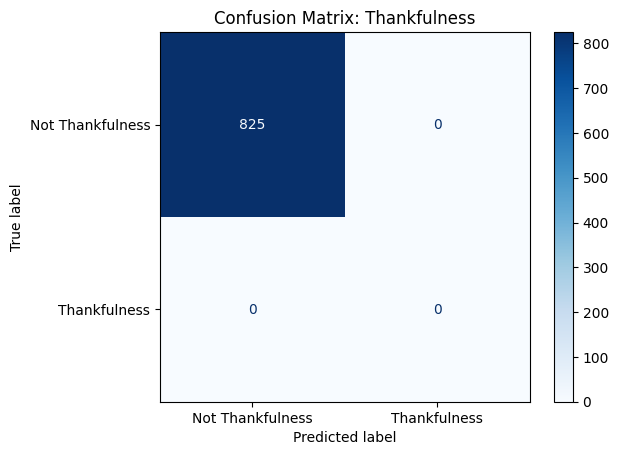

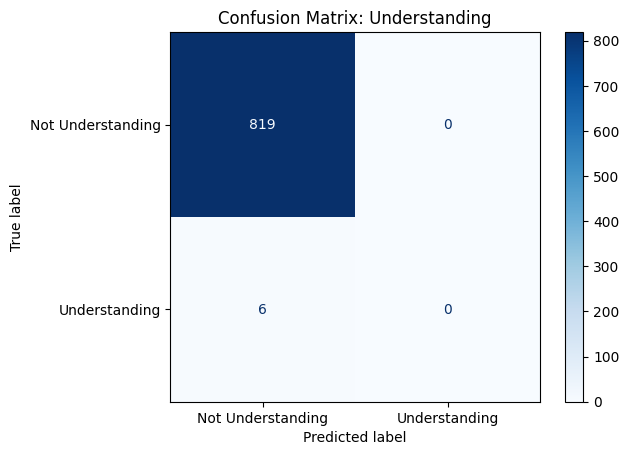

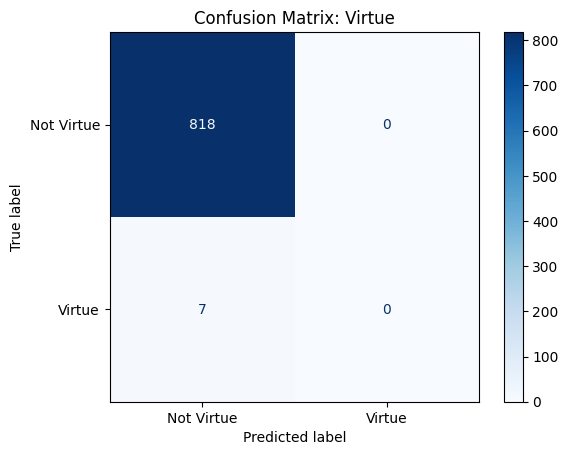

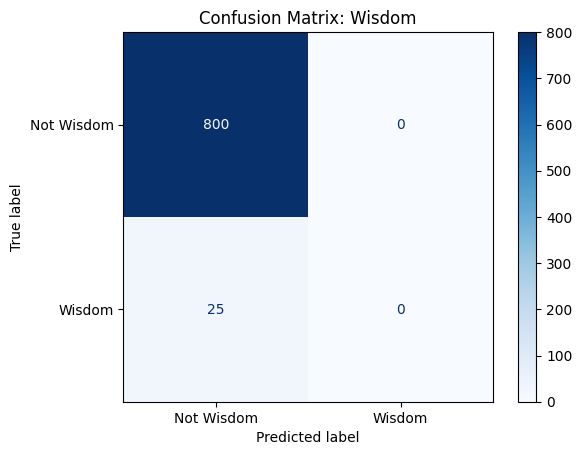

In [11]:
from sklearn.metrics import multilabel_confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Load best model
best_model_path = os.path.join(OUTPUT_DIR, 'best_model')
model = BertForSequenceClassification.from_pretrained(best_model_path).to(device)
model.eval()

all_preds = []
all_true = []

with torch.no_grad():
    for batch in tqdm(val_dl, desc="Confusion Matrix Eval"):
        input_ids = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids, attention_mask=mask)
        probs = torch.sigmoid(outputs.logits)

        preds = (probs > 0.5).int().cpu().numpy()
        all_preds.append(preds)
        all_true.append(labels.cpu().numpy())

y_pred = np.vstack(all_preds)
y_true = np.vstack(all_true)

# ---- MULTI-LABEL CONFUSION MATRIX ----
mcm = multilabel_confusion_matrix(y_true, y_pred)

label_names = list(label_map.keys())

# ---- Plot Per-Class Confusion Matrices ----
for i, label in enumerate(label_names):
    tn, fp, fn, tp = mcm[i].ravel()
    cm = np.array([[tn, fp],
                   [fn, tp]])

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Not " + label, label]
    )
    disp.plot(cmap='Blues', values_format='d')
    plt.title(f"Confusion Matrix: {label}")
    plt.show()
